# Evaluation Metrics Playbook

## Objective

The goal of this notebook is to understand how classification models should be evaluated in practical machine learning systems.

Rather than focusing on mathematical derivations, this notebook emphasizes:

- practical evaluation behavior
- business-oriented metric interpretation
- imbalanced classification challenges
- threshold-driven decision making
- probability reliability
- model failure analysis

The focus of this notebook is understanding practical evaluation behavior in real ML systems rather than mathematical derivations of metrics.

---

## Business Framing

We frame this problem as:

> Predicting whether a customer is likely to respond positively to a marketing campaign.

In this setting:

- False Positives may target uninterested customers, increasing marketing cost
- False Negatives may miss potential buyers and reduce conversions

This makes evaluation metrics important for business decision-making and campaign optimization

### Import Libraries

In [1]:
# Standard library
import random

# Third-party libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Local modules
from ml_playbook.config import DATA_DIR

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, f1_score, precision_score,\
recall_score, ConfusionMatrixDisplay

### Config

In [2]:
# Constants
RANDOM_STATE = 42
TARGET_COL = "Purchased"
TEST_SIZE = 0.25

# Paths
DATA_PATH = DATA_DIR / "Social_Network_Ads.csv"

# Reproducibility
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

### Load Dataset

In [3]:
df = pd.read_csv(DATA_PATH, header=0)
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)

Shape: (400, 3)

Data Types:
 Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object


**Dataset Overview**

We use the `Social_Network_Ads.csv` dataset containing:
- `Age` -> Customer age
- `EstimatedSalary` -> Estimated annual salary
- `Purchased` -> Whether the customer responded positively to the marketing campaign

This is a binary classification problem where the goal is to predict customer purchase behavior based on demographic information

In [4]:
# Preview
df.head(5)

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [6]:
print(y.value_counts(normalize=True))

Purchased
0    0.6425
1    0.3575
Name: proportion, dtype: float64


**Observation**
- The dataset shows moderate class imbalance
- The positive class (`Purchased = 1`) represents the minority class
- In imbalanced settings, accuracy alone may not reflect true model performance
- Metrics like Precision, Recall, F1-score, and ROC-AUC become more informative

### Train/Test split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE, 
                                                    random_state=RANDOM_STATE,
                                                    stratify=y)

**Notes**
- Stratified splitting preserves the original class distribution across training and test datasets
- This is important in imbalanced classification problems because random splitting can accidentally distort minority-class representation

### Column typing

In [8]:
# All columns are numeric
numeric_features = X_train.columns.tolist()

### Preprocessing skeleton

In [9]:
# feature-scaling preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features)
    ],
    remainder="drop"
)

### Train Logistic Regression Baseline Model

In [10]:
# pipeline with feature scaling
lr_baseline = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])
lr_baseline.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Generate Predictions and Probabilities

In [11]:
y_pred = lr_baseline.predict(X_test)
y_prob = lr_baseline.predict_proba(X_test)[:, 1]

In [12]:
# Metrics
lr_baseline_roc_auc = roc_auc_score(y_test, y_prob)
lr_baseline_accuracy = accuracy_score(y_test, y_pred)
lr_baseline_precision = precision_score(y_test, y_pred)
lr_baseline_recall = recall_score(y_test, y_pred)
lr_baseline_f1 = f1_score(y_test, y_pred)

# Confusion matrix
lr_baseline_cm = confusion_matrix(y_test, y_pred)

In [13]:
# Print metrics
print("=== Logistic Regression Baseline Metrics ===\n")

print(f"ROC-AUC  : {lr_baseline_roc_auc:.4f}")
print(f"Accuracy : {lr_baseline_accuracy:.4f}")
print(f"Precision: {lr_baseline_precision:.4f}")
print(f"Recall   : {lr_baseline_recall:.4f}")
print(f"F1-Score : {lr_baseline_f1:.4f}")

=== Logistic Regression Baseline Metrics ===

ROC-AUC  : 0.9102
Accuracy : 0.8400
Precision: 0.8571
Recall   : 0.6667
F1-Score : 0.7500


**Initial Evaluation Observations**
- The model achieves strong ROC-AUC performance, indicating good ranking capability between classes
- Precision is relatively high, meaning most customers predicted as likely buyers actually belong to the positive class
- Recall is lower than Precision, indicating the model still misses some potential buyers
- This creates an important business tradeoff:
    - improving Recall may identify more potential buyers
    - but may also increase marketing spend on uninterested customers
- Accuracy alone does not fully capture these tradeoffs

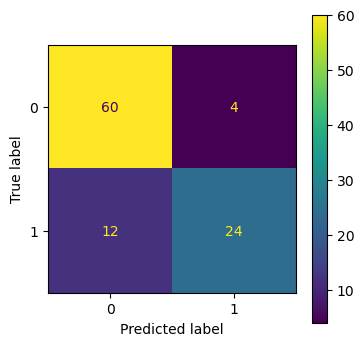

In [14]:
# Display confusion matrix
fig, ax = plt.subplots(figsize=(4, 4))

ConfusionMatrixDisplay(
    confusion_matrix=lr_baseline_cm,
    display_labels=["0", "1"]
).plot(ax=ax)

plt.show()

**Confusion Matrix Interpretation**
- True Negatives: Customers correctly identified as unlikely to purchase
- True Positives: Customers correctly identified as likely to purchase
- False Positives: Customers incorrectly targeted despite low purchase likelihood
- False Negatives: Potential buyers missed by the marketing campaign

In marketing systems, the acceptable balance between False Positives and False Negatives depends on campaign cost, customer reach, and conversion goals

**Confusion Matrix Insights**
- The model correctly identifies most non-buyers (`60` True Negatives)
- The model successfully identifies `24` potential buyers
- Only `4` uninterested customers are incorrectly targeted
- However, `12` potential buyers are still missed

This suggests the current model is relatively conservative in predicting positive outcomes:
- Precision remains high
- But some potential conversions are lost due to lower Recall